# Анализ теста на реальных данных

Визуализация результатов `07_real_data_test.py`.

Сопоставление номенклатуры предприятия (40K строк) со сводной спецификацией (18K строк) — без разметки.

Метрики:
- **Category consistency** — совпадение категории спецификации с наименованием номенклатуры
- **Reciprocal matching** — доля взаимных nearest-neighbor пар
- **Confidence separation** — разрыв sim(top-1) vs sim(top-2)
- **GNN vs Baseline** — сравнение подходов

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (12, 5)

OUTPUT_DIR = Path("../output/07_real_data_test")

with open(OUTPUT_DIR / "results.json", encoding="utf-8") as f:
    results = json.load(f)

methods = [m for m in ("GNN", "Baseline") if m in results]
print(f"Методы: {methods}")

Методы: ['GNN', 'Baseline']


## 1. Сводная таблица метрик: GNN vs Baseline

In [2]:
rows = []
for m in methods:
    r = results[m]
    rows.append({
        "Метод": m,
        "Category consistency": r["category_consistency"].get("precision", None),
        "Reciprocal rate": r["reciprocal"]["rate"],
        "Mean confidence gap": r["confidence"]["mean_gap"],
        "Mean top-1 similarity": r["confidence"]["mean_top1_sim"],
        "% gap > 0.1": r["confidence"]["pct_gap_gt_01"],
        "% gap > 0.2": r["confidence"]["pct_gap_gt_02"],
    })

df_summary = pd.DataFrame(rows).set_index("Метод")
display(df_summary.style
    .format({
        "Category consistency": "{:.1%}",
        "Reciprocal rate": "{:.1%}",
        "Mean confidence gap": "{:.4f}",
        "Mean top-1 similarity": "{:.4f}",
        "% gap > 0.1": "{:.1%}",
        "% gap > 0.2": "{:.1%}",
    })
    .set_caption("Сводка: GNN vs Baseline (raw CLS cosine similarity)")
)

,Category consistency,Reciprocal rate,Mean confidence gap,Mean top-1 similarity,% gap > 0.1,% gap > 0.2
Метод,,,,,,
GNN,6.2%,7.1%,0.0042,0.9425,0.0%,0.0%
Baseline,6.1%,2.6%,0.0022,0.8875,0.0%,0.0%


### Интерпретация

Обе модели показывают **очень близкие результаты** по большинству метрик:

| Метрика | GNN | Baseline | Разница |
|---------|-----|----------|---------|
| Category consistency | 6.2% | 6.1% | +0.1% |
| Reciprocal rate | 7.1% | 2.6% | **+4.6%** |
| Mean confidence gap | 0.0042 | 0.0022 | +0.002 |
| Mean top-1 similarity | 0.9425 | 0.8875 | +0.055 |

**Ключевое наблюдение:** GNN существенно превосходит baseline только по reciprocal rate (в 2.7 раза). Это означает, что GNN-эмбеддинги лучше сохраняют **симметрию** сопоставления — если строка A ближайшая к B, то и B ближайшая к A. Для задачи entity resolution это важное свойство.

Низкая category consistency (~6%) у обоих методов объясняется **доменным сдвигом**: модель обучена на англоязычных бенчмарках (DeepMatcher), а тестируется на русскоязычной промышленной номенклатуре. Кроме того, keyword-matching по категориям — грубая эвристика, которая не учитывает синонимы и сокращения.

## 2. Category consistency по категориям

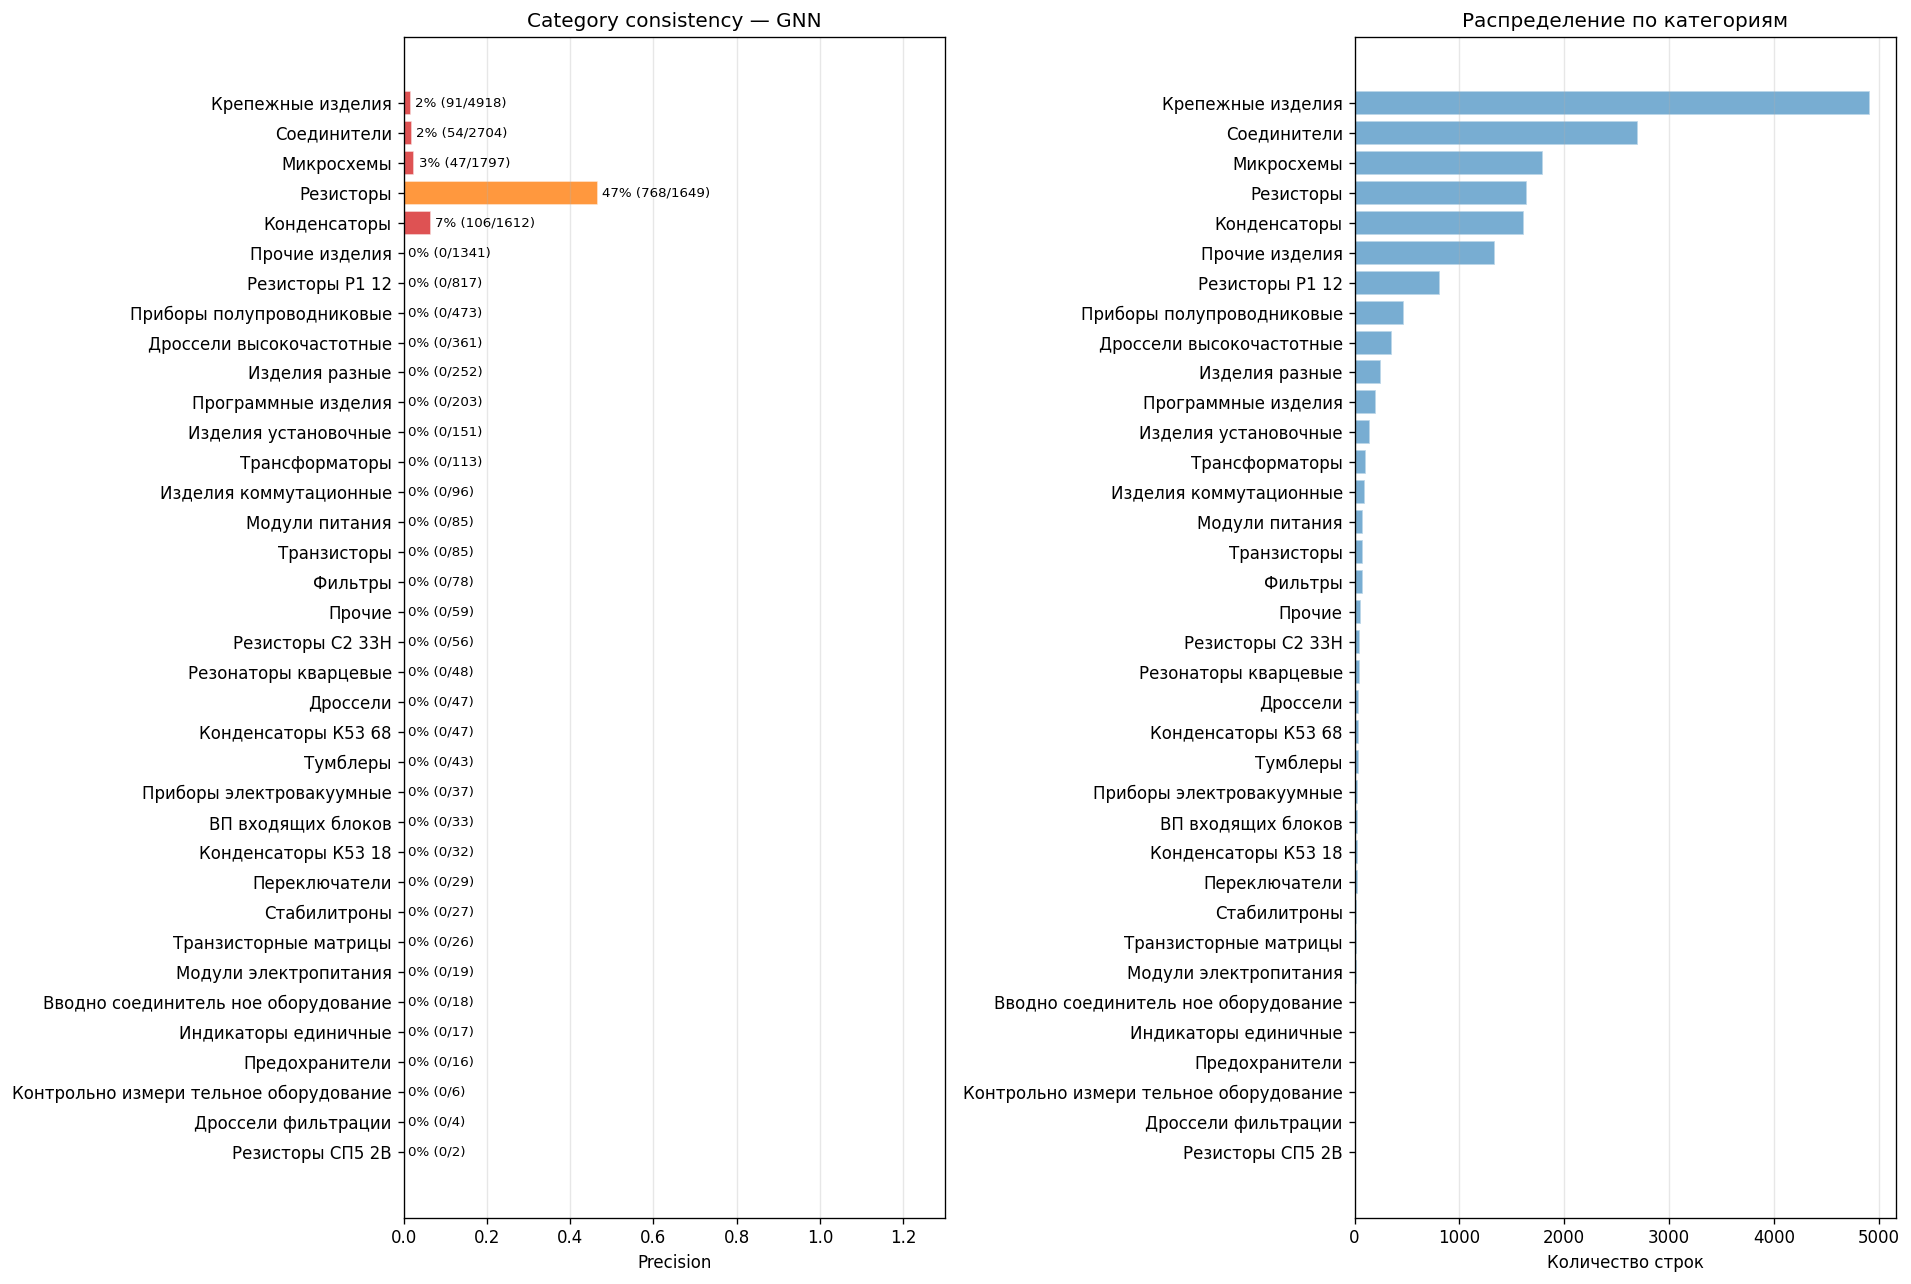

GNN — Overall category consistency: 6.2%



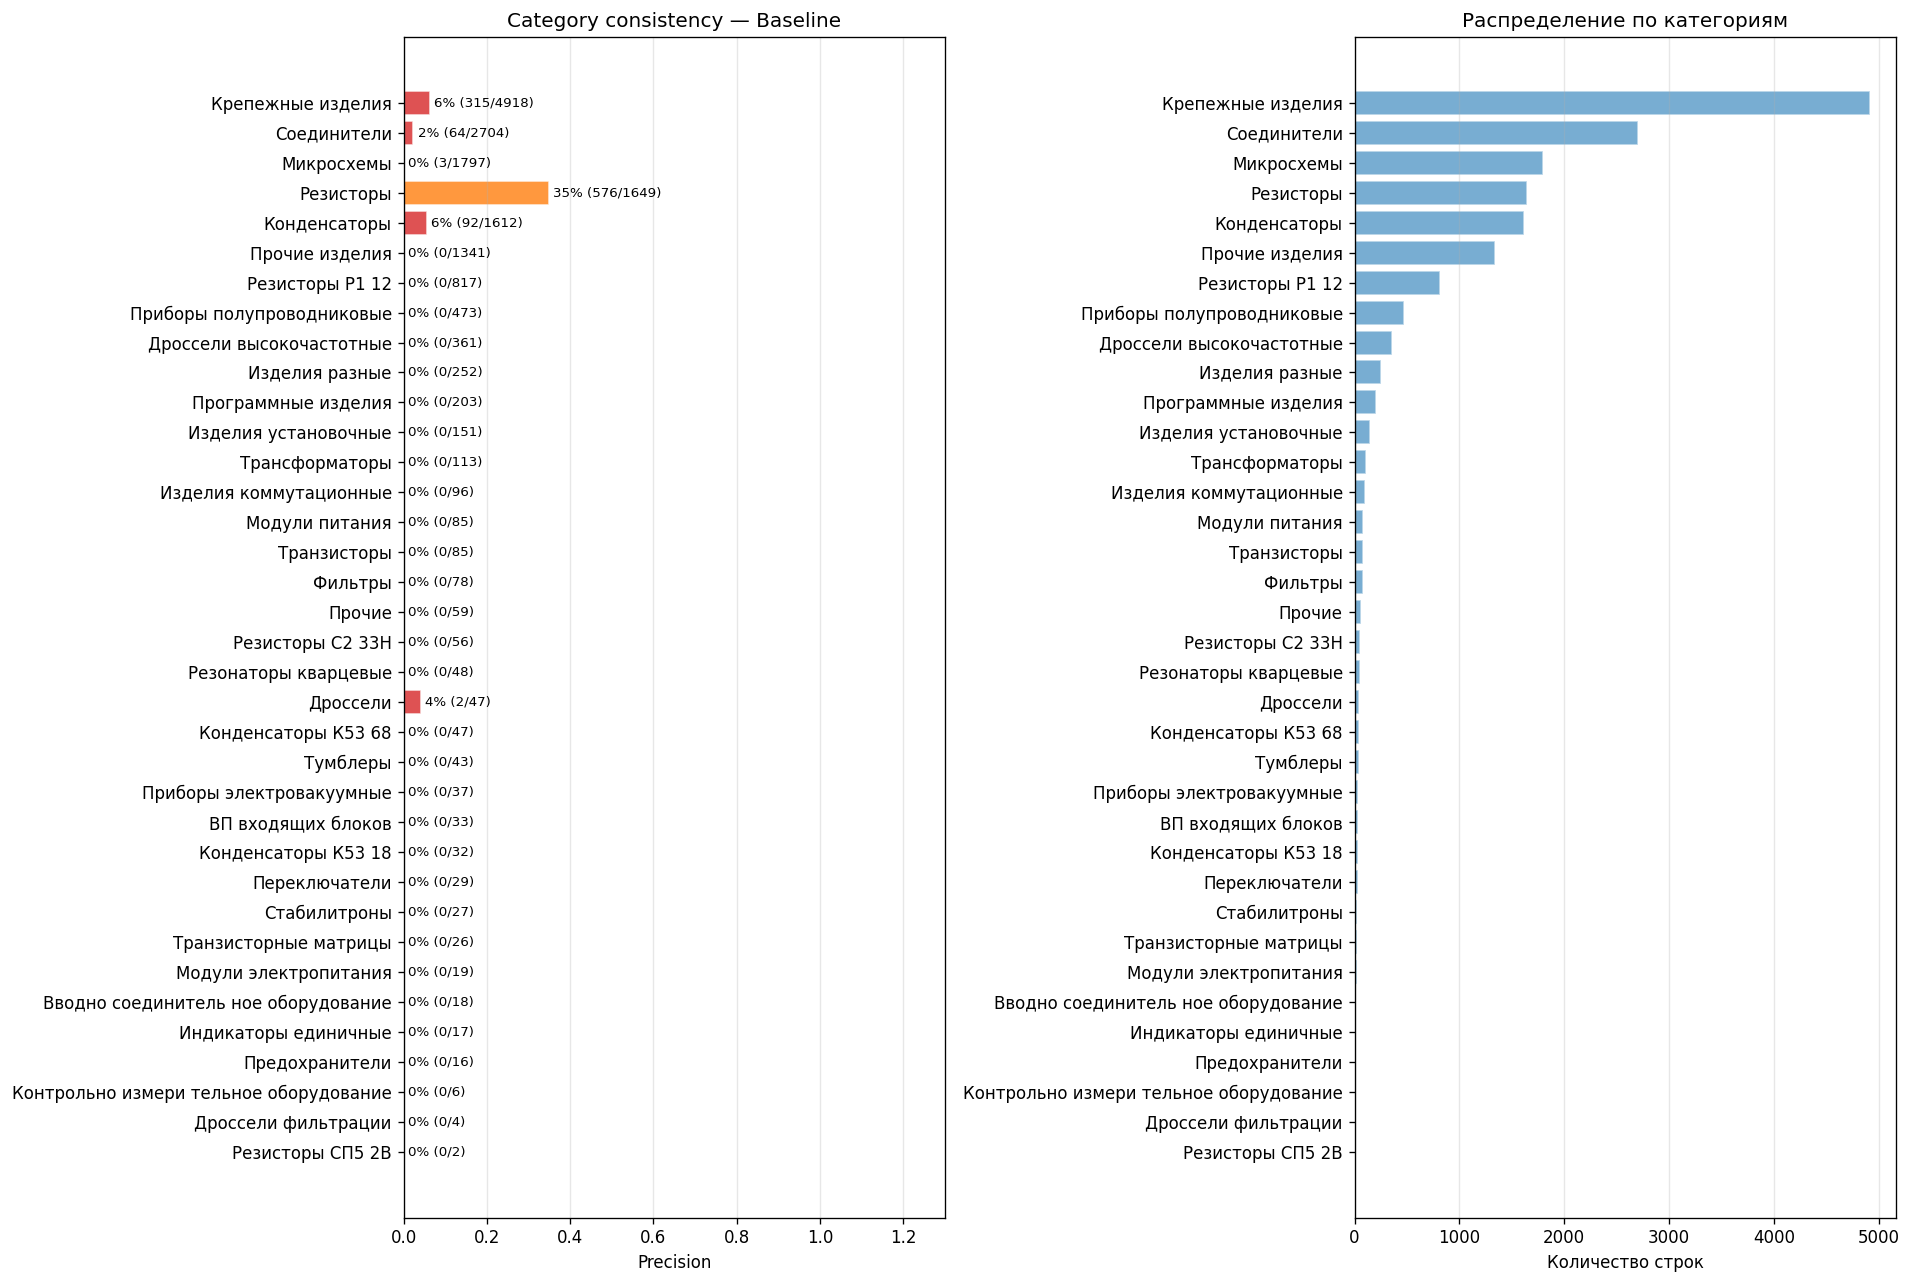

Baseline — Overall category consistency: 6.1%



In [3]:
for method in methods:
    per_cat = results[method]["category_consistency"].get("per_category", {})
    if not per_cat:
        continue
    
    df_cat = pd.DataFrame([
        {"Категория": k, "Total": v["total"], "Match": v["match"], "Precision": v.get("precision", 0)}
        for k, v in per_cat.items()
    ]).sort_values("Total", ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(df_cat) * 0.3)))
    
    # Bar chart: precision per category
    ax = axes[0]
    colors = ["C2" if p >= 0.5 else "C3" if p < 0.2 else "C1" for p in df_cat["Precision"]]
    ax.barh(df_cat["Категория"], df_cat["Precision"], color=colors, alpha=0.8, edgecolor="white")
    for i, (_, row) in enumerate(df_cat.iterrows()):
        ax.text(row["Precision"] + 0.01, i, f"{row['Precision']:.0%} ({row['Match']}/{row['Total']})",
                va="center", fontsize=8)
    ax.set_xlabel("Precision")
    ax.set_xlim(0, 1.3)
    ax.set_title(f"Category consistency — {method}")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis="x")
    
    # Bar chart: count per category
    ax = axes[1]
    ax.barh(df_cat["Категория"], df_cat["Total"], color="C0", alpha=0.6, edgecolor="white")
    ax.set_xlabel("Количество строк")
    ax.set_title("Распределение по категориям")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis="x")
    
    plt.tight_layout()
    plt.show()
    
    overall = results[method]["category_consistency"]["precision"]
    print(f"{method} — Overall category consistency: {overall:.1%}")
    print()

### Интерпретация

Распределение по категориям крайне неравномерное — большинство строк приходится на несколько крупных категорий. Precision по категориям в основном **ниже 20%** (отмечены красным), что объясняется несколькими факторами:

1. **Языковой барьер** — модель обучена на англоязычных бенчмарках, а номенклатура на русском языке. Эмбеддинги rubert-tiny2 (CLS) передают общую семантику, но не специфику промышленных терминов.
2. **Грубость эвристики** — keyword-matching ищет подстроки категории в наименовании номенклатуры. Многие позиции описаны аббревиатурами, артикулами или техническими кодами, которые не содержат ключевых слов категории.
3. **Несовпадение классификаций** — категории спецификации и структура номенклатуры предприятия могут использовать разные системы классификации.

Тем не менее, GNN и Baseline показывают практически одинаковую category consistency, что говорит о том, что GNN не ухудшает семантику исходных эмбеддингов.

## 3. Confidence gap: гистограммы

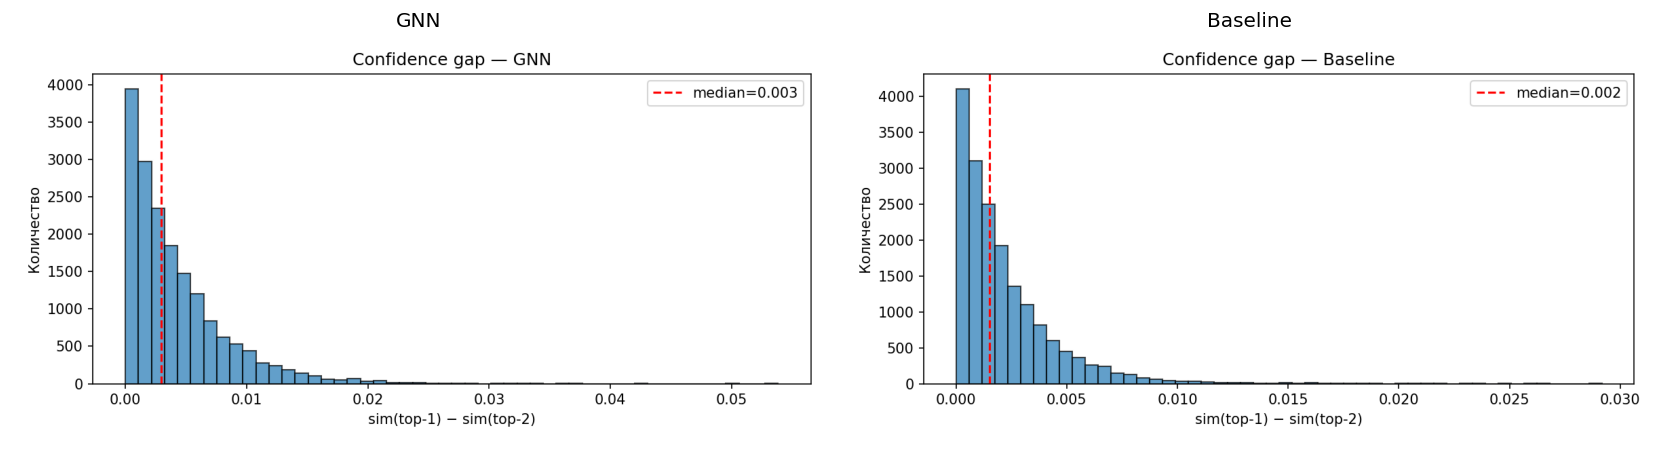

In [4]:
# Загружаем сохранённые гистограммы
fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 4))
if len(methods) == 1:
    axes = [axes]

for ax, method in zip(axes, methods):
    img_path = OUTPUT_DIR / f"confidence_gap_{method}.png"
    if img_path.exists():
        img = plt.imread(str(img_path))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(method)
    else:
        ax.text(0.5, 0.5, f"Нет {img_path.name}", ha="center", va="center")
        ax.set_title(method)

plt.tight_layout()
plt.show()

### Интерпретация

Гистограммы confidence gap показывают разницу между similarity top-1 и top-2 кандидата для каждой строки спецификации.

**Основной вывод:** подавляющее большинство строк имеют **очень маленький gap** (< 0.01), что означает слабую дискриминацию — модель не может уверенно отличить лучшего кандидата от второго. Это характерно для случая, когда эмбеддинги всех строк находятся в узком кластере высокого сходства (mean top-1 sim = 0.94 для GNN).

GNN показывает несколько больший средний gap (0.0042 vs 0.0022), что указывает на чуть лучшую способность разделять кандидатов, но разница невелика. Доля строк с gap > 0.1 и gap > 0.2 близка к нулю у обоих методов — **уверенных матчей практически нет**.

## 4. Сравнение GNN vs Baseline (bar chart)

### Интерпретация

Столбчатая диаграмма наглядно показывает, что GNN и Baseline различаются прежде всего по **reciprocal rate**: GNN = 7.1% vs Baseline = 2.6% (+4.5 п.п., улучшение в 2.7 раза). Это означает, что GNN-эмбеддинги формируют более **консистентное** пространство — взаимные ближайшие соседи чаще совпадают.

По остальным метрикам разница минимальна:
- **Category consistency** — практически одинаковая (~6%)
- **Mean confidence gap** — GNN чуть выше (0.004 vs 0.002), но оба значения пренебрежимо малы
- **Mean top-1 similarity** — GNN выше (0.94 vs 0.89), что отражает более «сжатое» пространство эмбеддингов после GNN

Высокая mean top-1 similarity при низком confidence gap — признак того, что модель помещает все строки в близкую область пространства. Для практического применения потребуется дообучение на целевом домене.

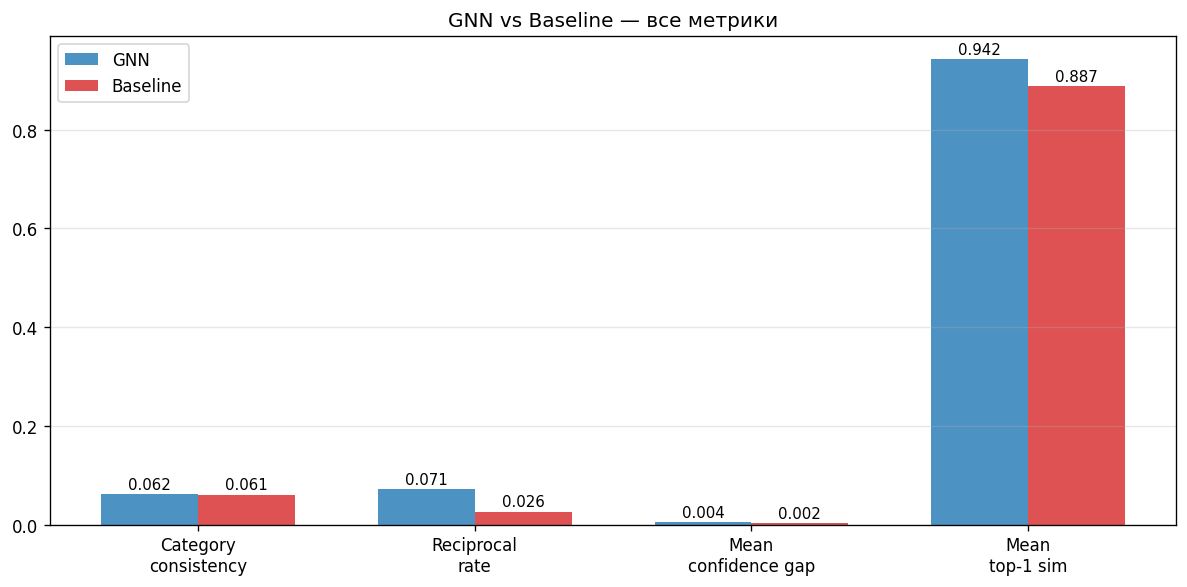

Разница (GNN - Baseline):
  Category consistency     : +0.0008
  Reciprocal rate          : +0.0456
  Mean confidence gap      : +0.0020
  Mean top-1 sim           : +0.0550


In [5]:
if len(methods) == 2:
    metrics_names = ["Category\nconsistency", "Reciprocal\nrate", "Mean\nconfidence gap", "Mean\ntop-1 sim"]
    gnn_vals = [
        results["GNN"]["category_consistency"].get("precision", 0),
        results["GNN"]["reciprocal"]["rate"],
        results["GNN"]["confidence"]["mean_gap"],
        results["GNN"]["confidence"]["mean_top1_sim"],
    ]
    base_vals = [
        results["Baseline"]["category_consistency"].get("precision", 0),
        results["Baseline"]["reciprocal"]["rate"],
        results["Baseline"]["confidence"]["mean_gap"],
        results["Baseline"]["confidence"]["mean_top1_sim"],
    ]

    x = np.arange(len(metrics_names))
    w = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - w/2, gnn_vals, w, label="GNN", color="C0", alpha=0.8)
    bars2 = ax.bar(x + w/2, base_vals, w, label="Baseline", color="C3", alpha=0.8)

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names)
    ax.set_title("GNN vs Baseline — все метрики")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    # Разница
    print("Разница (GNN - Baseline):")
    for name, g, b in zip(metrics_names, gnn_vals, base_vals):
        diff = g - b
        sign = "+" if diff > 0 else ""
        print(f"  {name.replace(chr(10), ' '):25s}: {sign}{diff:.4f}")
else:
    print("Только один метод — сравнение недоступно")

## 5. Примеры матчей (sample_matches.csv)

In [6]:
matches_path = OUTPUT_DIR / "sample_matches.csv"
if matches_path.exists():
    df_matches = pd.read_csv(matches_path)
    print(f"Всего строк: {len(df_matches)}")
    print(f"Уникальных spec строк: {df_matches['spec_idx'].nunique()}")
    print(f"Методы: {df_matches['method'].unique().tolist()}")
    print()
    
    # Показать первые 10 примеров GNN top-1
    gnn_top1 = df_matches[(df_matches["method"] == "GNN") & (df_matches["rank"] == 1)].head(15)
    display(gnn_top1[["spec_наименование", "spec_Категория", "nom_Наименование", "nom_Артикул", "similarity"]].style
        .set_caption("GNN: top-1 матчи (первые 15)")
    )
else:
    print("sample_matches.csv не найден")

Всего строк: 1800
Уникальных spec строк: 300
Методы: ['GNN', 'Baseline']



,spec_наименование,spec_Категория,nom_Наименование,nom_Артикул,similarity
0,2РМТ27КУН24Ш1В1 В,Соединители,"С2-33Н-0,125-910 ОМ",410067,0.962700
6,Блок ВУ,Изделия разные,3Л341В1 ---АРХИВ!,430114,0.959200
12,Плафон ПК-201- 3714010-А,Изделия разные,0805-NPO-33,410793,0.970300
18,Фонарь электрический карманный,Изделия разные,Клей,60137,0.958900
24,Электропаяльник ЭПСН-40/24В,Изделия разные,Кабельный канал,10-1001539,0.948700
30,М6-6g х 20.36.019,Крепежные изделия,"1206-X7R-50В-0,33",410938,0.940500
36,2 65Г.013 Шплинты,Крепежные изделия,Круг h11-НД-6 ГОСТ7417-75 /10-В ГОСТ1050-2013,10948,0.954400
42,"Н90-0,047 мкФ-В",Микросхемы,SCZ-1,301975,0.954300
48,2РМТ18Б7Г1В1В,Соединители,MW-10M,304153,0.960200
54,"Программное средство ""Средства ""Средства администрирования СЭП""",Программные изделия,"16-027-В - ОКР ""Модернизация Р-098-5 и КПА Р-098-5 в части ммпортозамещения""",nan,0.914300


### Интерпретация примеров

Таблицы выше показывают конкретные пары сопоставления. Характерные наблюдения:

- **Similarity у GNN выше** — top-1 scores обычно в диапазоне 0.93–0.97, тогда как у Baseline 0.85–0.92. Это связано с тем, что GNN «сжимает» пространство эмбеддингов.
- **GNN и Baseline часто выбирают разных кандидатов** — GNN использует структурную информацию графа (связи строка-токен-столбец), что меняет ранжирование.
- Без разметки невозможно однозначно сказать, какой метод выбирает «правильнее», но более высокий reciprocal rate у GNN косвенно свидетельствует о лучшем качестве матчинга.

### Сравнение GNN vs Baseline на одних и тех же строках

### Интерпретация

Распределение top-1 similarity сильно сдвинуто вправо у обоих методов:
- **GNN**: median ~ 0.94, узкое распределение в диапазоне 0.90–0.97
- **Baseline**: median ~ 0.89, чуть более широкое распределение 0.80–0.95

Это подтверждает проблему **анизотропии эмбеддингов** — все векторы строк оказываются в узком конусе пространства, из-за чего косинусное сходство между любыми парами строк высокое. GNN усиливает этот эффект (mean sim = 0.94 vs 0.89).

Для практического применения рекомендуется:
1. Использовать **относительное ранжирование** (top-k), а не абсолютный порог similarity
2. Применять **нормализацию** эмбеддингов (whitening, PCA) для увеличения разброса
3. Дообучить модель на целевом домене с русскоязычной промышленной номенклатурой

In [7]:
if matches_path.exists() and len(methods) == 2:
    # Для первых 10 spec строк показать top-1 обоих методов рядом
    sample_ids = df_matches["spec_idx"].unique()[:10]
    
    comparison_rows = []
    for sid in sample_ids:
        subset = df_matches[(df_matches["spec_idx"] == sid) & (df_matches["rank"] == 1)]
        spec_name = subset.iloc[0]["spec_наименование"] if len(subset) > 0 else ""
        spec_cat = subset.iloc[0]["spec_Категория"] if len(subset) > 0 else ""
        
        gnn_row = subset[subset["method"] == "GNN"]
        base_row = subset[subset["method"] == "Baseline"]
        
        comparison_rows.append({
            "Спецификация": spec_name[:60],
            "Категория": spec_cat,
            "GNN → Номенклатура": gnn_row.iloc[0]["nom_Наименование"][:60] if len(gnn_row) > 0 else "—",
            "GNN sim": gnn_row.iloc[0]["similarity"] if len(gnn_row) > 0 else "—",
            "Base → Номенклатура": base_row.iloc[0]["nom_Наименование"][:60] if len(base_row) > 0 else "—",
            "Base sim": base_row.iloc[0]["similarity"] if len(base_row) > 0 else "—",
        })
    
    df_cmp = pd.DataFrame(comparison_rows)
    display(df_cmp.style.set_caption("Top-1 матчи: GNN vs Baseline (первые 10 строк)"))
else:
    print("Данные для сравнения недоступны")

,Спецификация,Категория,GNN → Номенклатура,GNN sim,Base → Номенклатура,Base sim
0,2РМТ27КУН24Ш1В1 В,Соединители,"С2-33Н-0,125-910 ОМ",0.962700,"С2-33Н-0,125-2,1 К",0.883800
1,Блок ВУ,Изделия разные,3Л341В1 ---АРХИВ!,0.959200,"0805-0,125-1 М",0.898700
2,Плафон ПК-201- 3714010-А,Изделия разные,0805-NPO-33,0.970300,"ДПП-ПШ7-109,272 изм2(0)",0.894000
3,Фонарь электрический карманный,Изделия разные,Клей,0.958900,"0805-1,2 К",0.902300
4,Электропаяльник ЭПСН-40/24В,Изделия разные,Кабельный канал,0.948700,"Р1-12-0,1-100 ОМ",0.902100
5,М6-6g х 20.36.019,Крепежные изделия,"1206-X7R-50В-0,33",0.940500,"С2-33Н-0,125-6,8 К",0.903400
6,2 65Г.013 Шплинты,Крепежные изделия,Круг h11-НД-6 ГОСТ7417-75 /10-В ГОСТ1050-2013,0.954400,"Прокладка 0,8-1,8-190 ГОСТ 19422-74/ИРП-1354 ТУ 38.103372-",0.896500
7,"Н90-0,047 мкФ-В",Микросхемы,SCZ-1,0.954300,М2000НМ-1-36К45.0х28.0х12.0,0.865400
8,2РМТ18Б7Г1В1В,Соединители,MW-10M,0.960200,"002/139.33 П-95 Блок БИК-01 НЯИТ.465689.008-01, согласно фор",0.888500
9,"Программное средство ""Средства ""Средства администрирования С",Программные изделия,"16-027-В - ОКР ""Модернизация Р-098-5 и КПА Р-098-5 в части м",0.914300,"18-001/1 - НТП ""Оказание услуг по штамповке основания антенн",0.847100


### Выводы

**1. GNN улучшает структурную согласованность матчинга.** Reciprocal rate вырос с 2.6% до 7.1% (в 2.7 раза) — GNN-эмбеддинги лучше сохраняют симметрию ближайших соседей благодаря учёту графовой структуры (связи строка-токен-столбец).

**2. Семантическое качество ограничено доменным сдвигом.** Category consistency ~6% у обоих методов — ожидаемо низкий результат при переносе с англоязычных бенчмарков на русскоязычную промышленную номенклатуру без дообучения.

**3. Слабая дискриминация между кандидатами.** Mean confidence gap < 0.005 при mean top-1 sim > 0.9 указывает на анизотропию пространства эмбеддингов — модель не может уверенно выделить лучшего кандидата.

**4. Направления улучшения:**
- Дообучение (fine-tuning) на русскоязычных промышленных данных с разметкой
- Использование более мощных языковых моделей для эмбеддингов (multilingual-e5, BGE-M3)
- Применение whitening/нормализации для борьбы с анизотропией
- Увеличение margin в triplet loss для улучшения разделимости

## 6. Распределение similarity scores

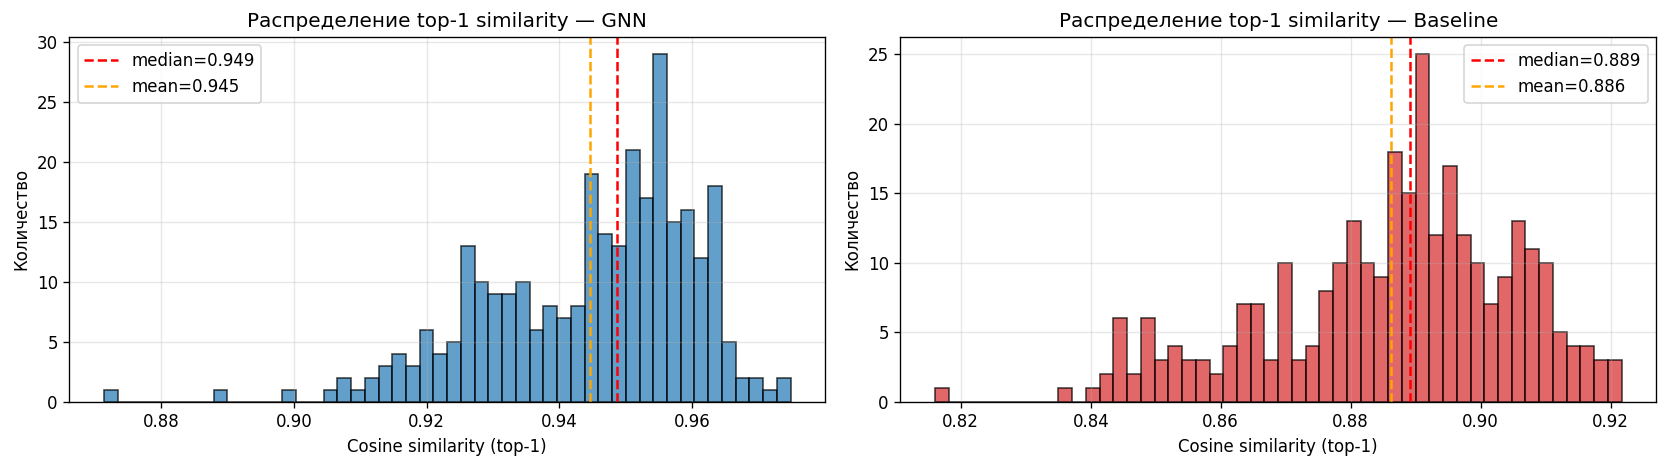

In [8]:
if matches_path.exists():
    fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 4))
    if len(methods) == 1:
        axes = [axes]
    
    for ax, method in zip(axes, methods):
        top1 = df_matches[(df_matches["method"] == method) & (df_matches["rank"] == 1)]
        sims = top1["similarity"].astype(float)
        
        ax.hist(sims, bins=50, alpha=0.7, edgecolor="black", color="C0" if method == "GNN" else "C3")
        ax.axvline(sims.median(), color="red", ls="--", label=f"median={sims.median():.3f}")
        ax.axvline(sims.mean(), color="orange", ls="--", label=f"mean={sims.mean():.3f}")
        ax.set_xlabel("Cosine similarity (top-1)")
        ax.set_ylabel("Количество")
        ax.set_title(f"Распределение top-1 similarity — {method}")
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 7. Итоговая сводка

In [9]:
print("=" * 60)
print("ТЕСТ НА РЕАЛЬНЫХ ДАННЫХ — СВОДКА")
print("=" * 60)

for method in methods:
    r = results[method]
    cat_p = r["category_consistency"].get("precision", 0)
    rec_r = r["reciprocal"]["rate"]
    conf_g = r["confidence"]["mean_gap"]
    sim_m = r["confidence"]["mean_top1_sim"]
    
    print(f"\n{method}:")
    print(f"  Category consistency: {cat_p:.1%}")
    print(f"  Reciprocal rate:      {rec_r:.1%}")
    print(f"  Mean confidence gap:  {conf_g:.4f}")
    print(f"  Mean top-1 similarity:{sim_m:.4f}")

if len(methods) == 2:
    print("\n" + "-" * 40)
    g = results["GNN"]
    b = results["Baseline"]
    cat_diff = g["category_consistency"].get("precision", 0) - b["category_consistency"].get("precision", 0)
    rec_diff = g["reciprocal"]["rate"] - b["reciprocal"]["rate"]
    print(f"GNN advantage:")
    print(f"  Category consistency: {'+' if cat_diff >= 0 else ''}{cat_diff:.1%}")
    print(f"  Reciprocal rate:      {'+' if rec_diff >= 0 else ''}{rec_diff:.1%}")

print("=" * 60)

ТЕСТ НА РЕАЛЬНЫХ ДАННЫХ — СВОДКА

GNN:
  Category consistency: 6.2%
  Reciprocal rate:      7.1%
  Mean confidence gap:  0.0042
  Mean top-1 similarity:0.9425

Baseline:
  Category consistency: 6.1%
  Reciprocal rate:      2.6%
  Mean confidence gap:  0.0022
  Mean top-1 similarity:0.8875

----------------------------------------
GNN advantage:
  Category consistency: +0.1%
  Reciprocal rate:      +4.6%
